In [34]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict

In [35]:
#defining state

class BMIState(TypedDict):
  weight_kg:float
  hieght_m:float
  bmi:float
  category:str

In [36]:
def calculate_bmi(state: BMIState)->BMIState:
  weight=state['weight_kg']
  height=state['hieght_m']  
  
  bmi = weight / (height ** 2)
  
  state['bmi']=round(bmi,2)
  
  return state

In [37]:
def label_emi(state:BMIState)->BMIState:
  bmi=state['bmi']
  
  if bmi<18.5:
    state['category']="underweight"
  elif 18.5<=bmi<25:
    state['category']="normal"
  else:
    state['category']="obese"
    
  return state

In [38]:
graph=StateGraph(BMIState)


#add nodes to graph
graph.add_node('calculate_bmi',calculate_bmi)
graph.add_node('label_emi',label_emi)

#add edges to graph
graph.add_edge(START,'calculate_bmi')
graph.add_edge('calculate_bmi','label_emi')
graph.add_edge('label_emi',END)

#compile the graph
workflow=graph.compile()



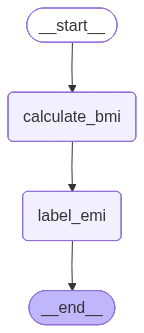

In [39]:
workflow

In [40]:
#execute the grpah
output_state=workflow.invoke({'weight_kg':80,'hieght_m':1.73})

In [41]:
output_state

{'weight_kg': 80, 'hieght_m': 1.73, 'bmi': 26.73, 'category': 'obese'}